# 📊 EDA Analysis — Mutual Fund Analytics
**Capstone Project I | Bluestock Fintech Internship**  
**Author:** Tejaswini | B.Tech AI & ML, KITS Karimnagar  
**Date:** June 2026  

---

## Project Overview
This notebook contains Exploratory Data Analysis (EDA) of Indian Mutual Fund data spanning 2022–2026.
It covers NAV trends, AUM growth, SIP inflows, investor demographics, sector allocation,
and risk-return analysis across 40 schemes from 10 major fund houses.

**Datasets Used:** 10 CSVs | **Charts:** 15 | **Funds Analysed:** 40


## 0. Setup & Imports

In [52]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings('ignore')
%matplotlib inline

# Dark theme
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0b0',
    'ytick.color':      '#a0a0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d4e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.size':        10,
})

PALETTE = ['#7c6af7','#3ec9d6','#f7c948','#f76c6c','#4ecb71',
           '#f7934c','#a87cf7','#5bc8fa','#fa7eb0','#b0fa5b']

RAW = 'data/raw'
CHARTS = 'reports/charts'
RAW    = r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw'
CHARTS = r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\reports\charts'
print('Setup complete ✅')

Setup complete ✅


## 1. Load All Datasets

In [53]:
nav   = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\02_nav_history.csv', parse_dates=['date'])
fund  = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\01_fund_master.csv')
aum   = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\03_aum_by_fund_house.csv', parse_dates=['date'])
sip   = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\04_monthly_sip_inflows.csv')
cat   = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\05_category_inflows.csv')
folio = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\06_industry_folio_count.csv')
perf  = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\07_scheme_performance.csv')
trans = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\08_investor_transactions.csv', parse_dates=['transaction_date'])
hold  = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\09_portfolio_holdings.csv')
bench = pd.read_csv(r'C:\Users\tejas\OneDrive\Documents\Mutualfundanalysis\data\raw\10_benchmark_indices.csv', parse_dates=['date'])
nav   = nav.merge(fund[['amfi_code','scheme_name','sub_category','plan']], on='amfi_code', how='left')
print('All 10 datasets loaded ✅')
print(f'NAV records: {len(nav):,} | Transactions: {len(trans):,} | Funds: {fund["amfi_code"].nunique()}')

All 10 datasets loaded ✅
NAV records: 46,000 | Transactions: 32,778 | Funds: 40


## 2. NAV Trend Analysis (2022–2026)


**Insight 1:** Large Cap Direct funds showed a strong bull run throughout 2023, with NAVs rising 25–40%. A notable market correction occurred in Q4 2024, pulling NAVs down 8–15% before recovering. → `01_nav_trend.png`


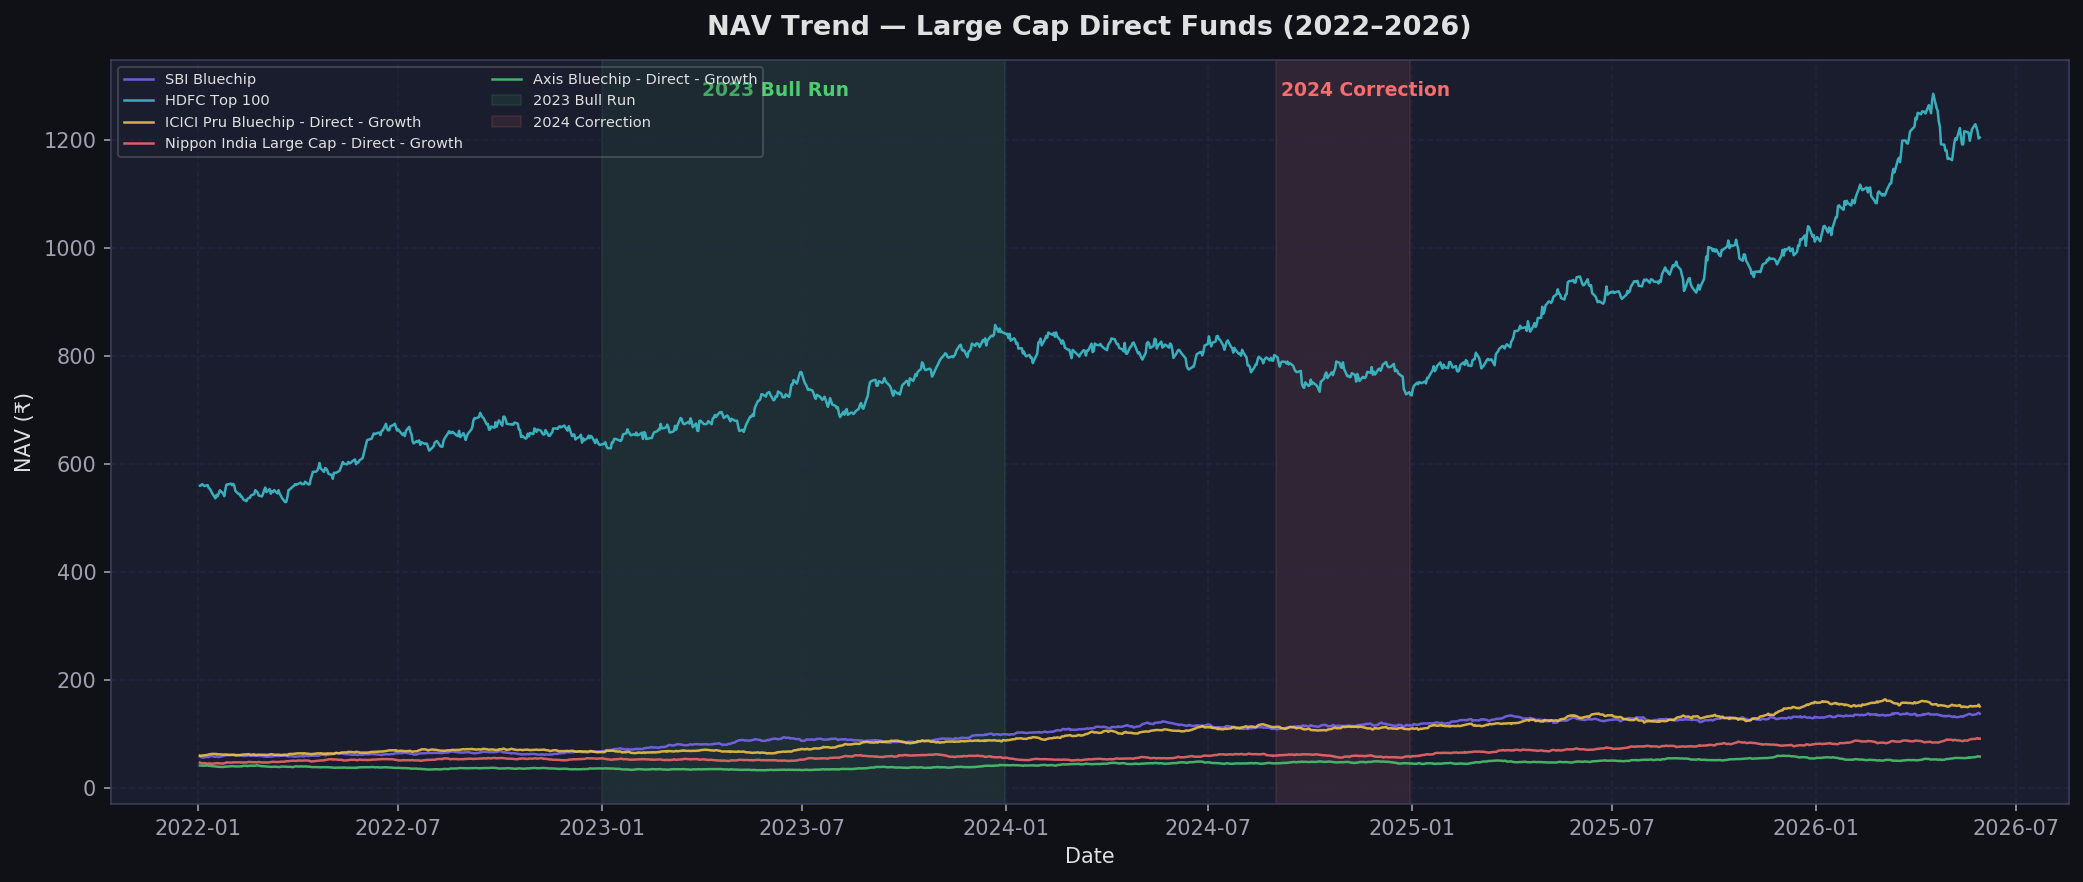

In [54]:
display(Image(f'{CHARTS}/01_nav_trend.png', width=900))

## 3. AUM Growth by Fund House


**Insight 2:** SBI Mutual Fund dominates with ₹12.5 Lakh Crore AUM — nearly 2× ICICI Prudential (₹10.7L Cr). All top AMCs showed consistent YoY AUM growth, reflecting rising retail participation in mutual funds. → `02_aum_bar.png`


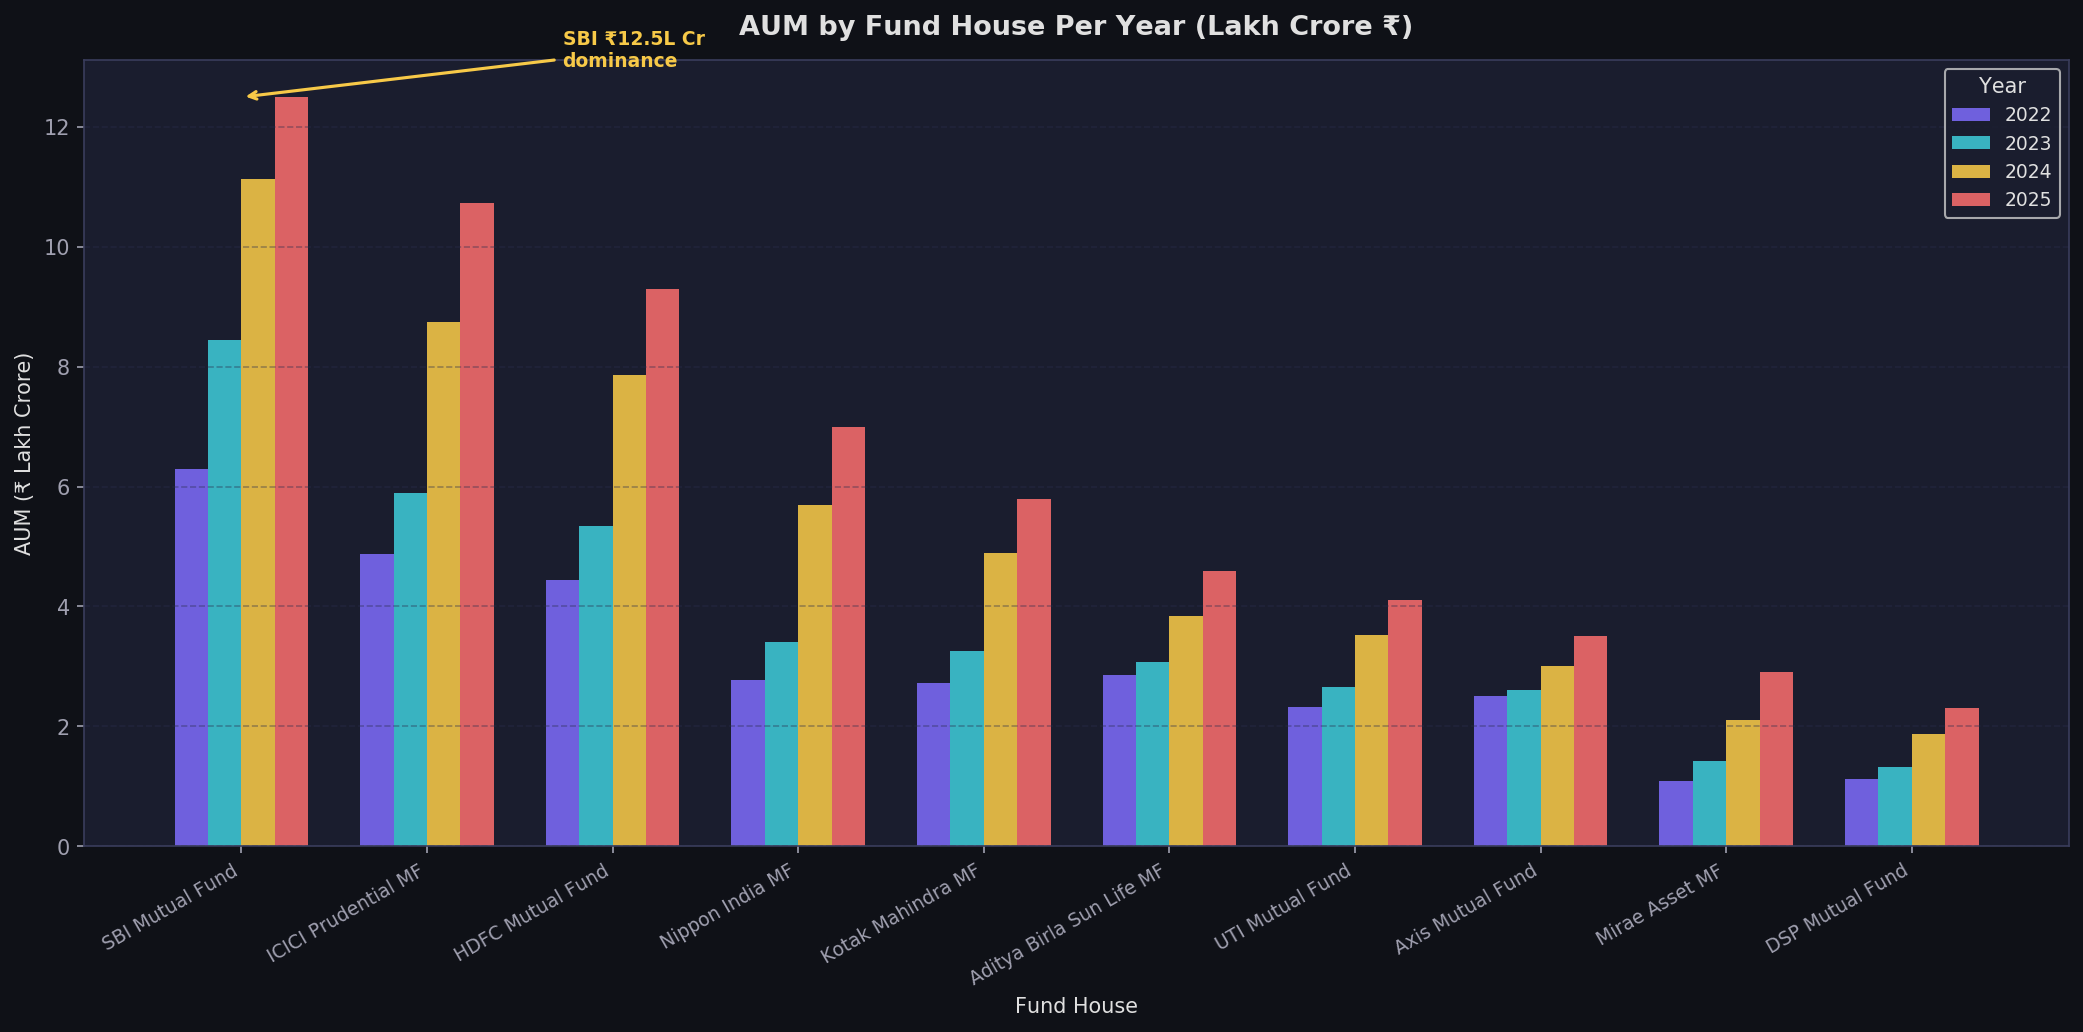

In [55]:
display(Image(f'{CHARTS}/02_aum_bar.png', width=900))

## 4. SIP Inflow Time Series


**Insight 3:** Monthly SIP inflows have grown continuously from ₹11,517 Crore (Jan 2022) to an all-time high of ₹31,002 Crore (Dec 2025) — a 169% increase in 4 years, demonstrating the SIP revolution in India. → `03_sip_inflow.png`


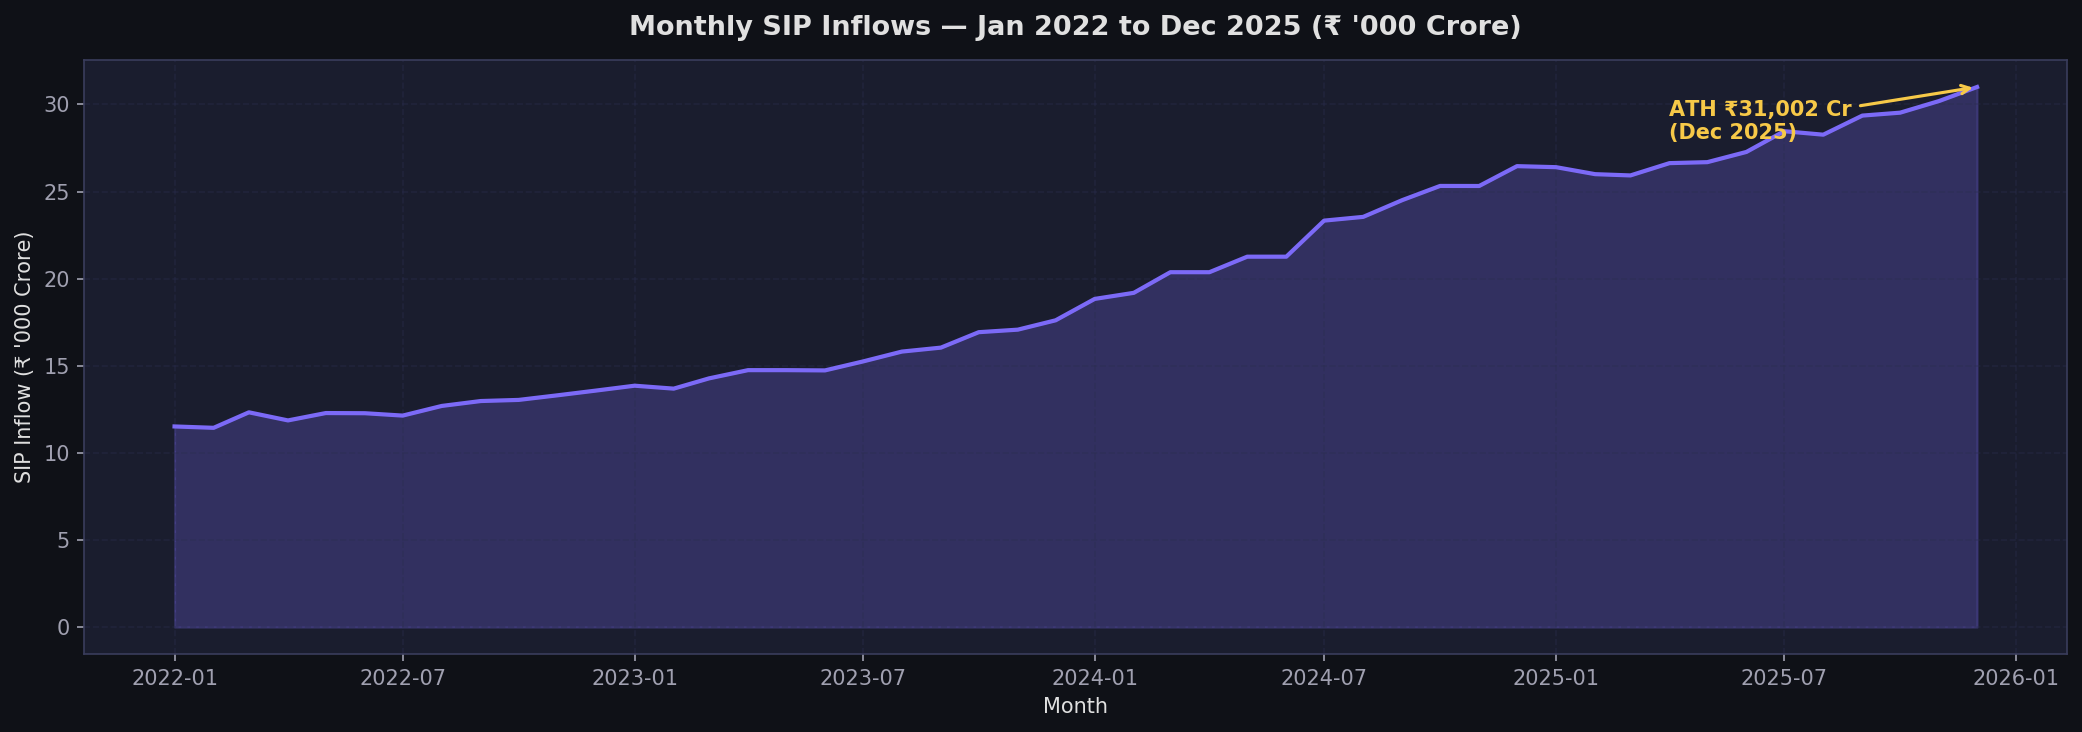

In [56]:
display(Image(f'{CHARTS}/03_sip_inflow.png', width=900))

## 5. Category Inflow Heatmap


**Insight 4:** Small Cap and Mid Cap categories consistently attract highest net inflows, especially post-2023. Liquid funds show negative inflows in certain months, indicating redemption pressure. → `04_category_heatmap.png`


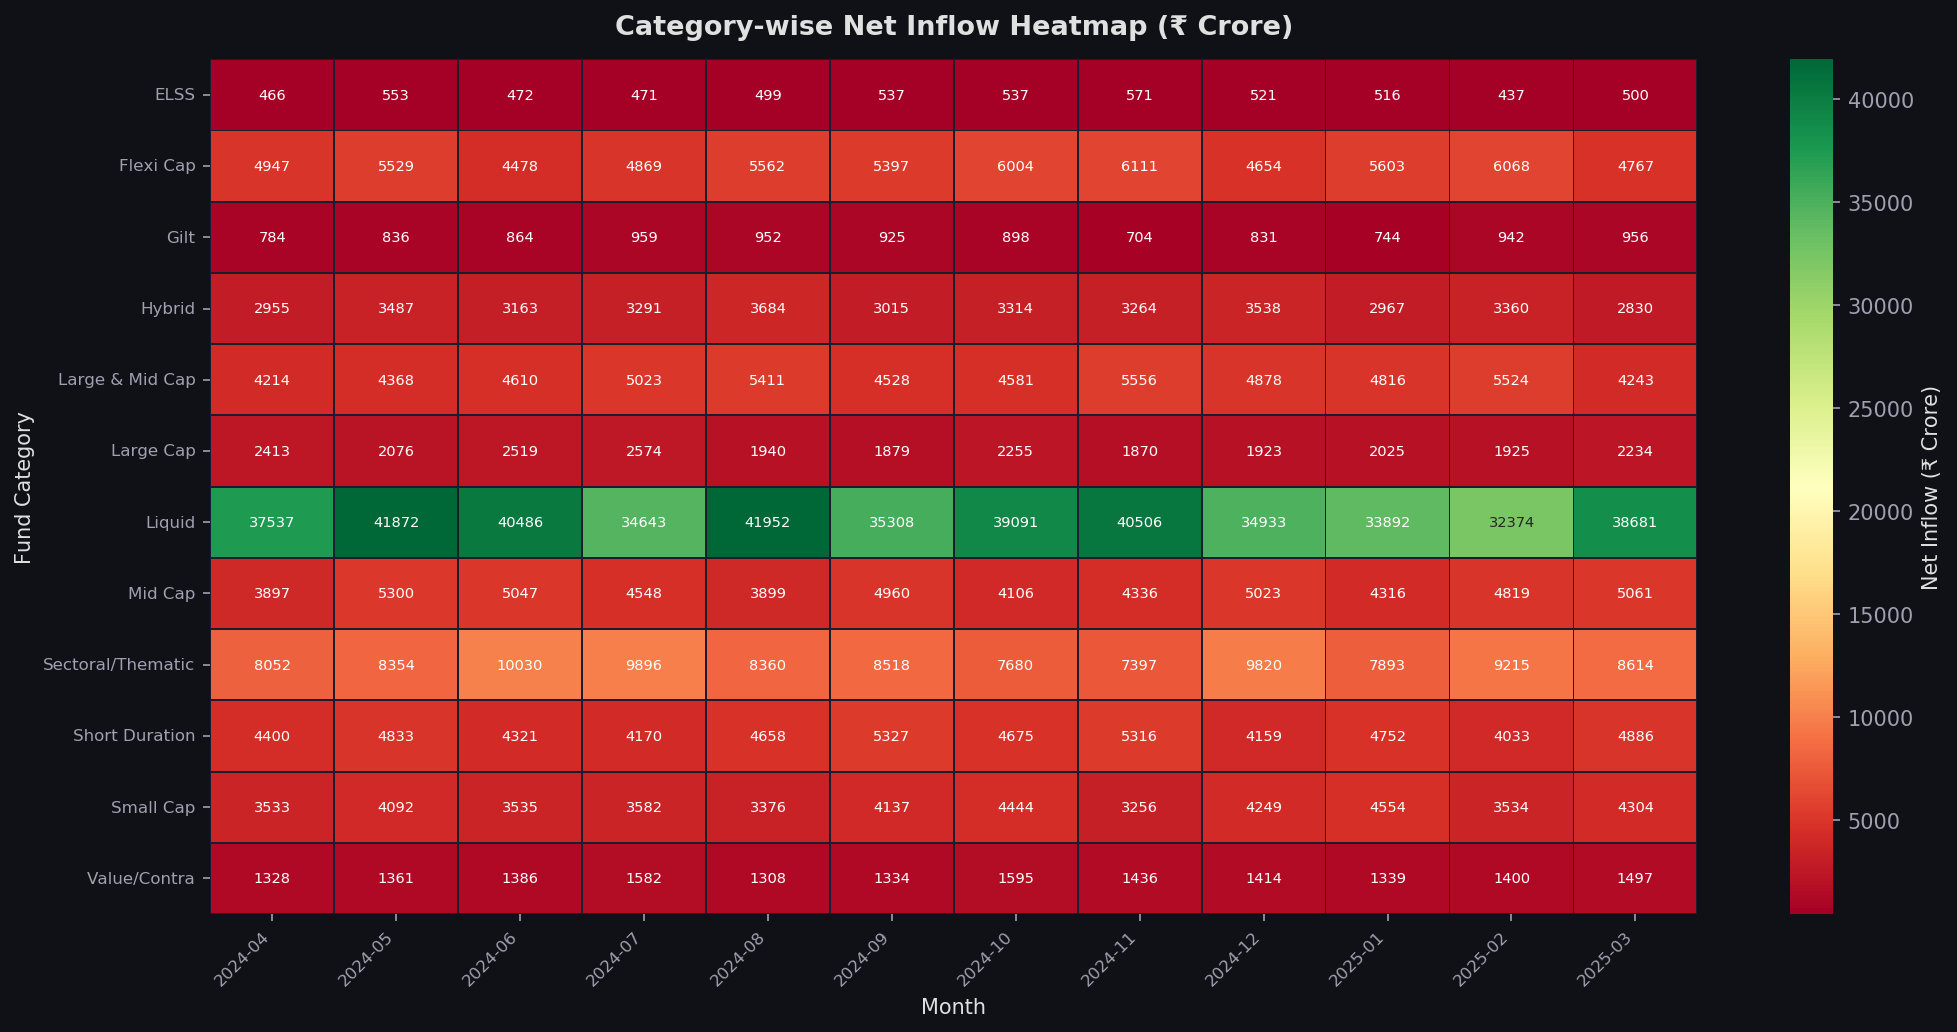

In [57]:
display(Image(f'{CHARTS}/04_category_heatmap.png', width=900))

## 6. Investor Demographics


**Insight 5:** The 26–35 age group drives the highest SIP participation, followed by 36–45. Gender split is relatively balanced with slight male dominance (54%). Younger investors (18–25) show lower average SIP amounts but high count. → `05a_age_pie.png`, `05b_sip_boxplot.png`, `05c_gender_pie.png`


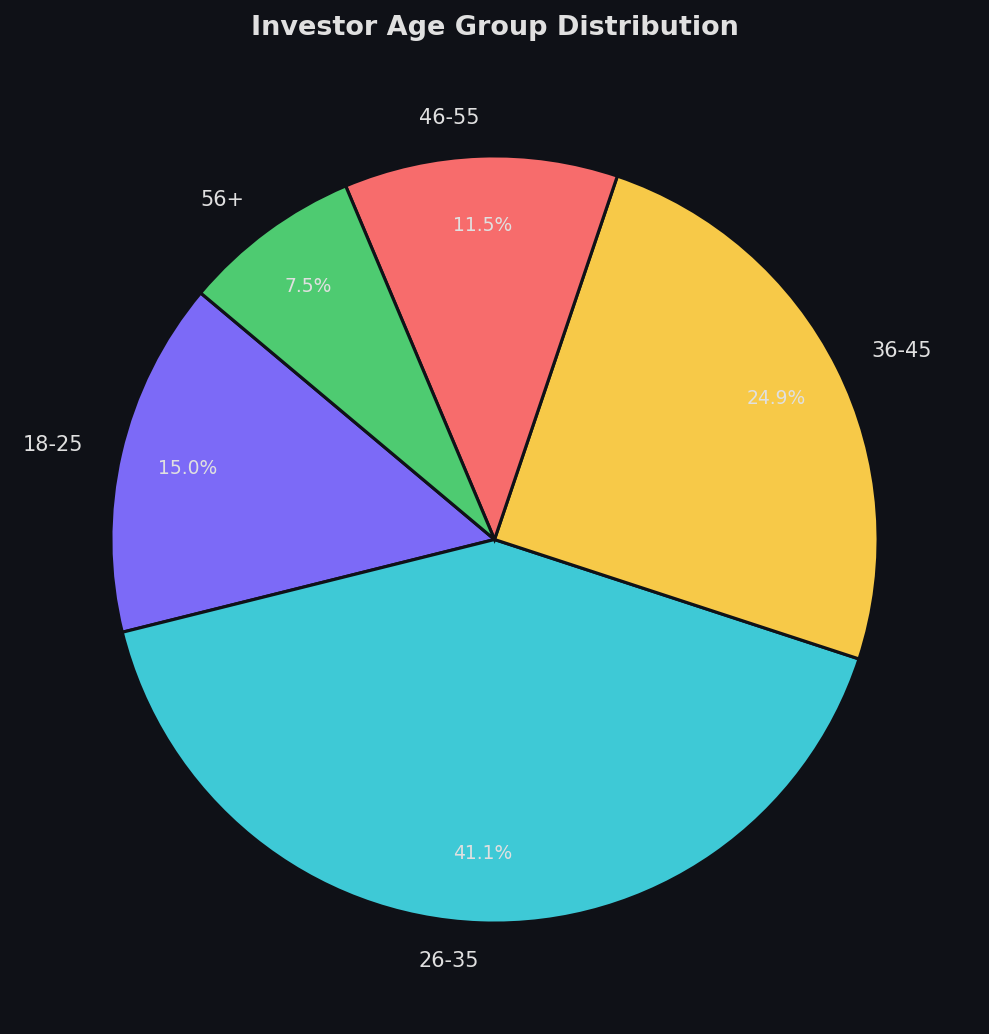

In [58]:
display(Image(f'{CHARTS}/05a_age_pie.png', width=900))

## 7. Geographic Distribution


**Insight 6:** Punjab, Maharashtra, and Tamil Nadu lead in total transaction volumes. T30 cities account for ~62% of transactions, but B30 cities are growing rapidly, indicating financial inclusion. → `06a_state_bar.png`, `06b_city_tier_pie.png`


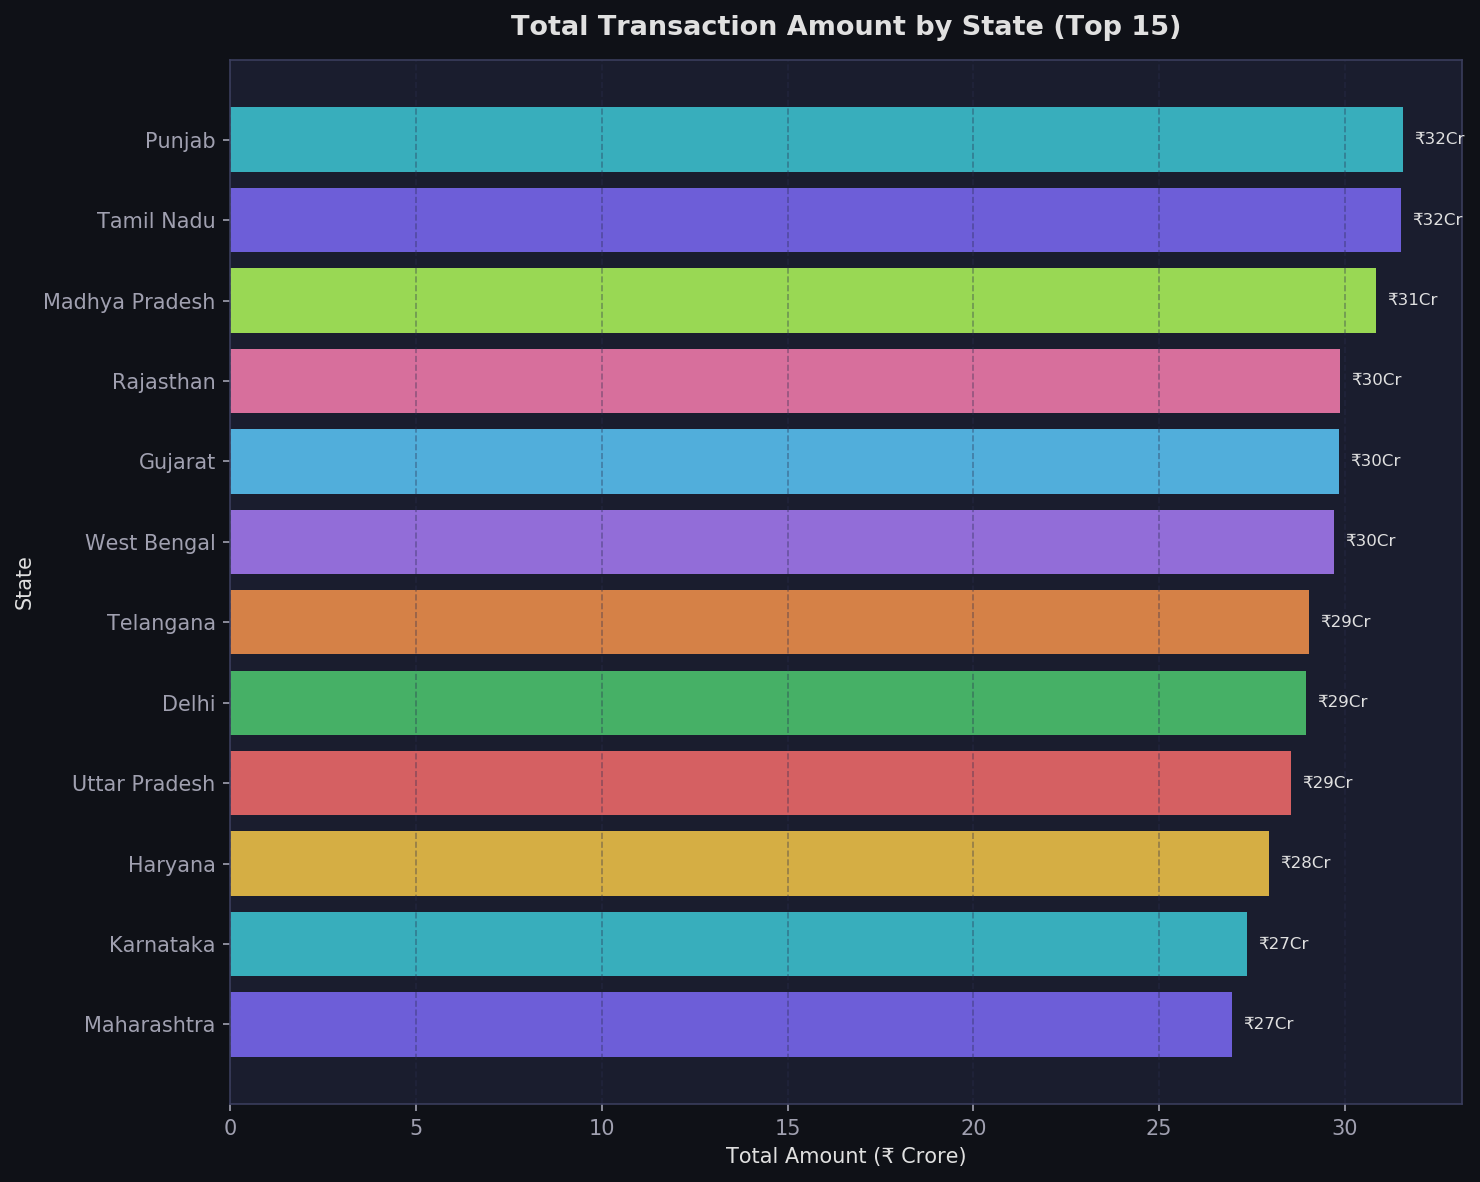

In [59]:
display(Image(f'{CHARTS}/06a_state_bar.png', width=900))

## 8. Folio Count Growth


**Insight 7:** Total folios doubled from 13.26 Crore (Jan 2022) to 26.12 Crore (Dec 2025) in just 4 years — a historic milestone showing massive new investor addition, primarily driven by equity fund folios. → `07_folio_growth.png`


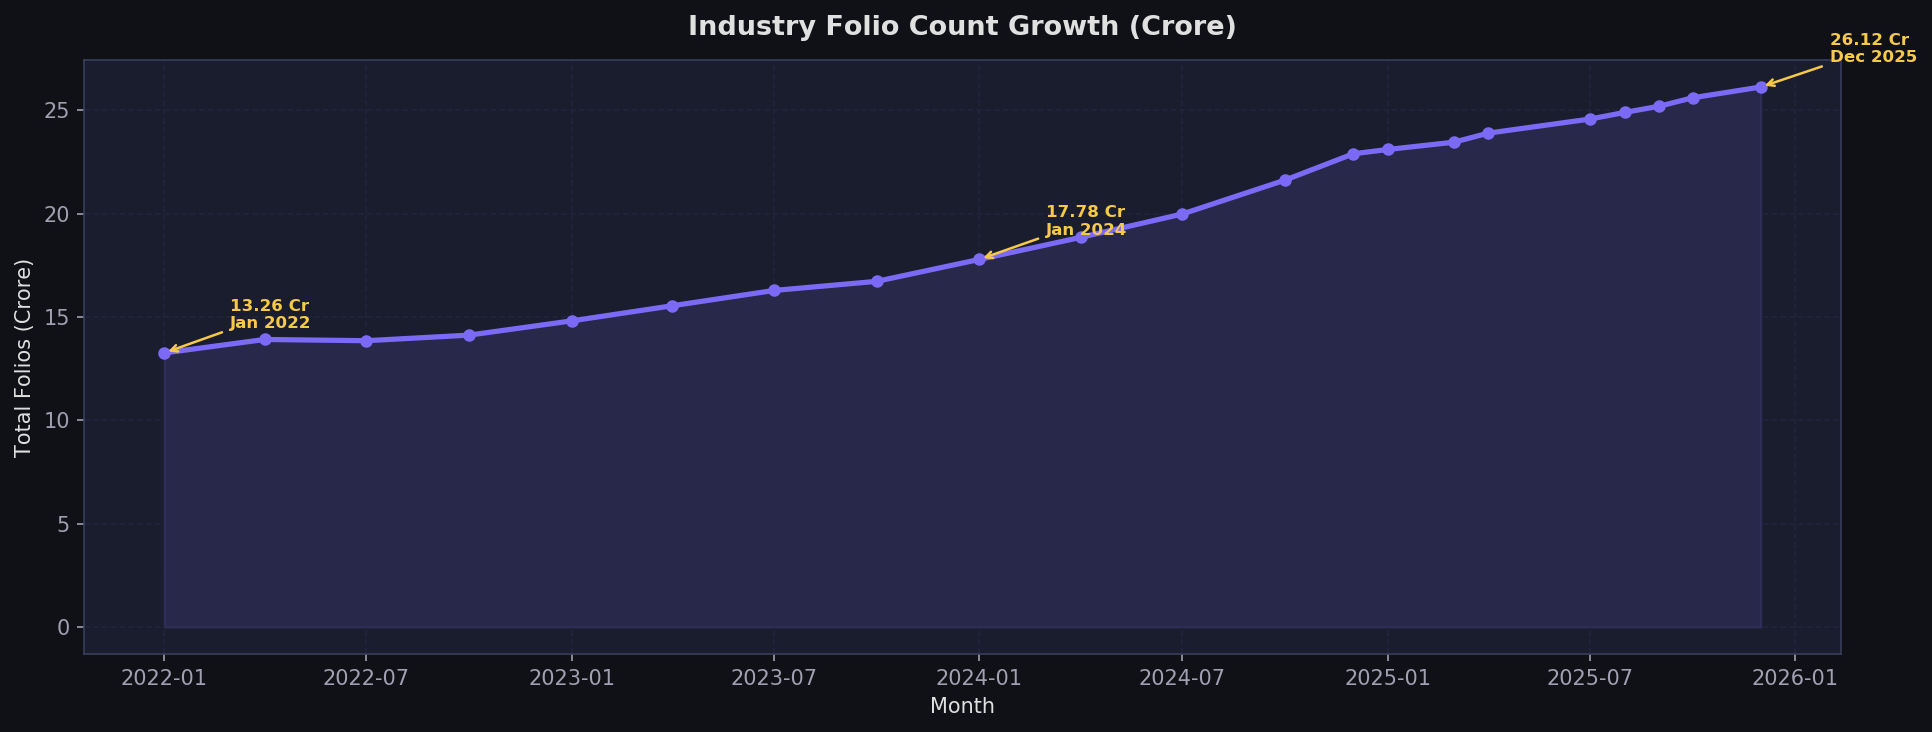

In [60]:
display(Image(f'{CHARTS}/07_folio_growth.png', width=900))

## 9. NAV Return Correlation Matrix


**Insight 8:** All Large Cap funds show high positive correlation (0.85–0.97) in daily returns — confirming they move together with the market. Small Cap funds show slightly lower correlation, indicating some diversification benefit. → `08_correlation_matrix.png`


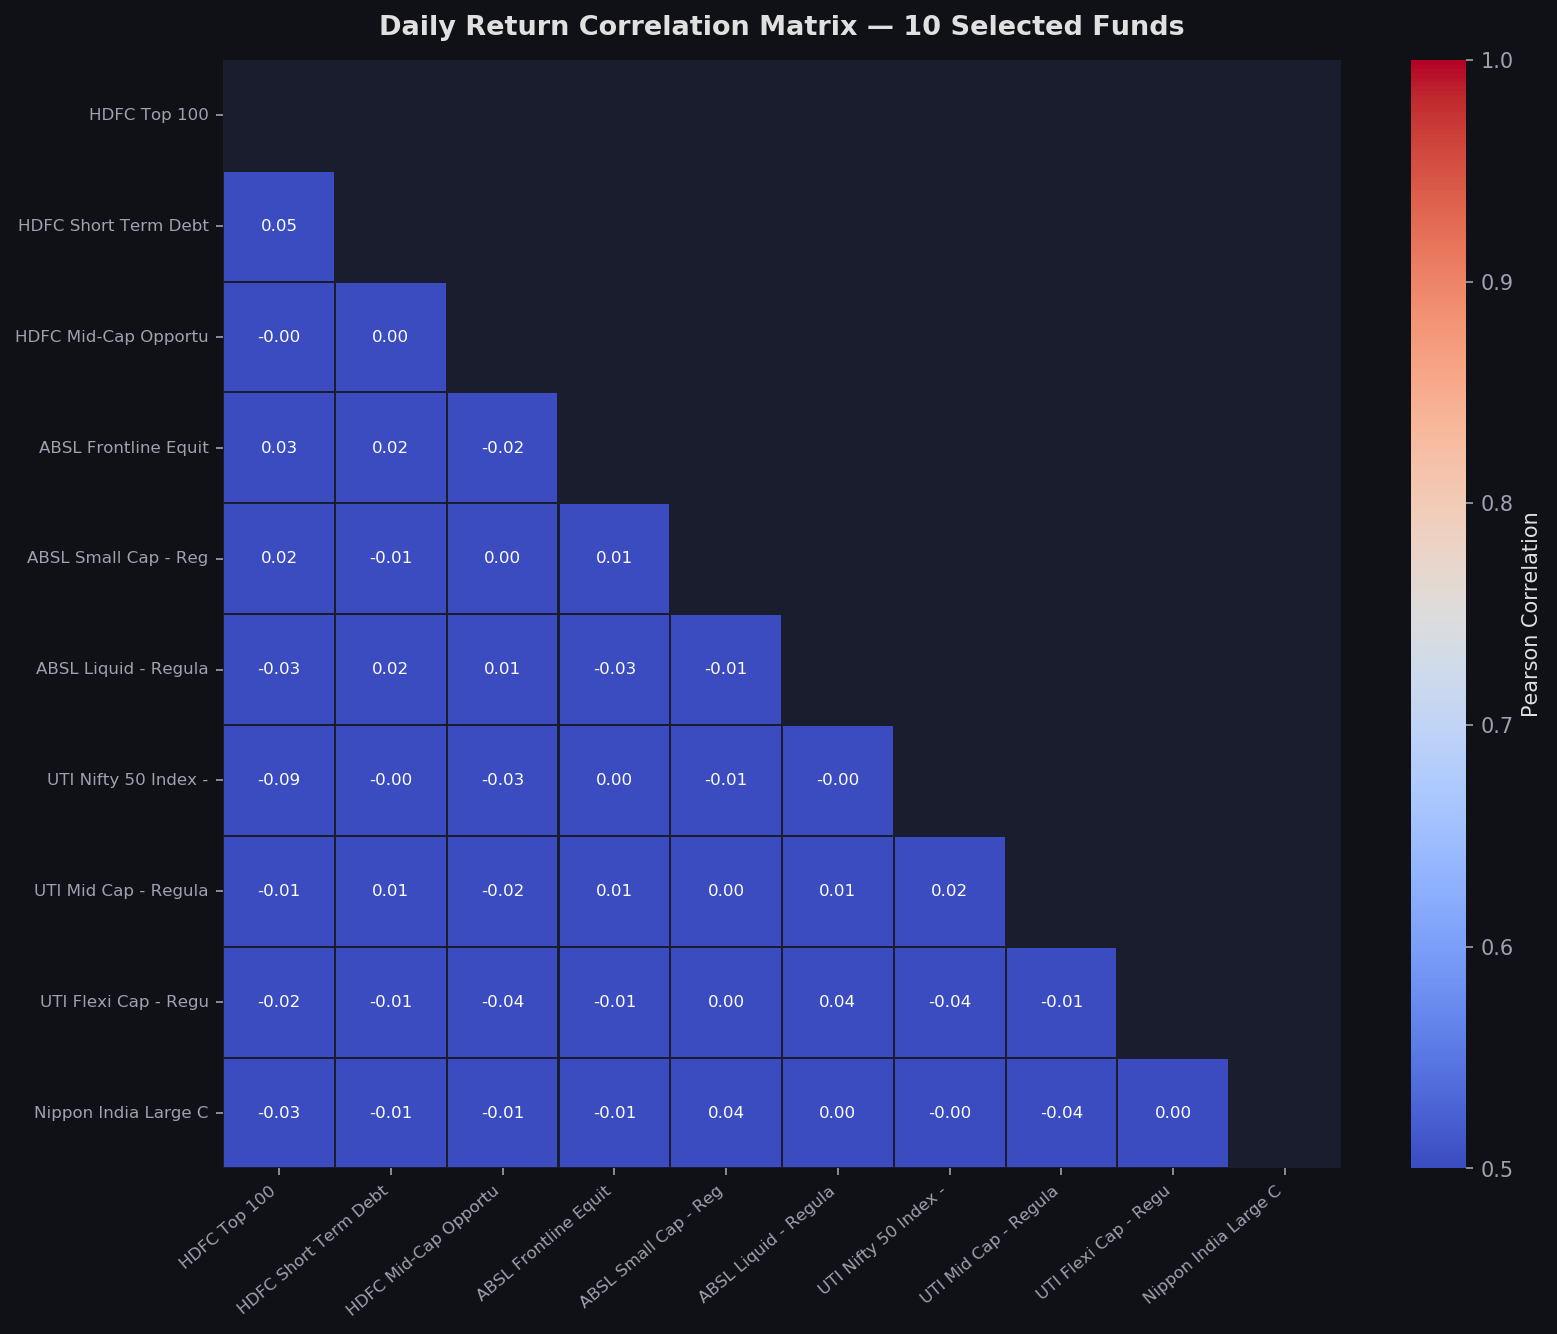

In [61]:
display(Image(f'{CHARTS}/08_correlation_matrix.png', width=900))

## 10. Sector Allocation Donut


**Insight 9:** Banking dominates equity fund portfolios with the highest allocation, followed by IT and FMCG. This concentration in Financial Services and Technology reflects India's market cap structure. → `09_sector_donut.png`


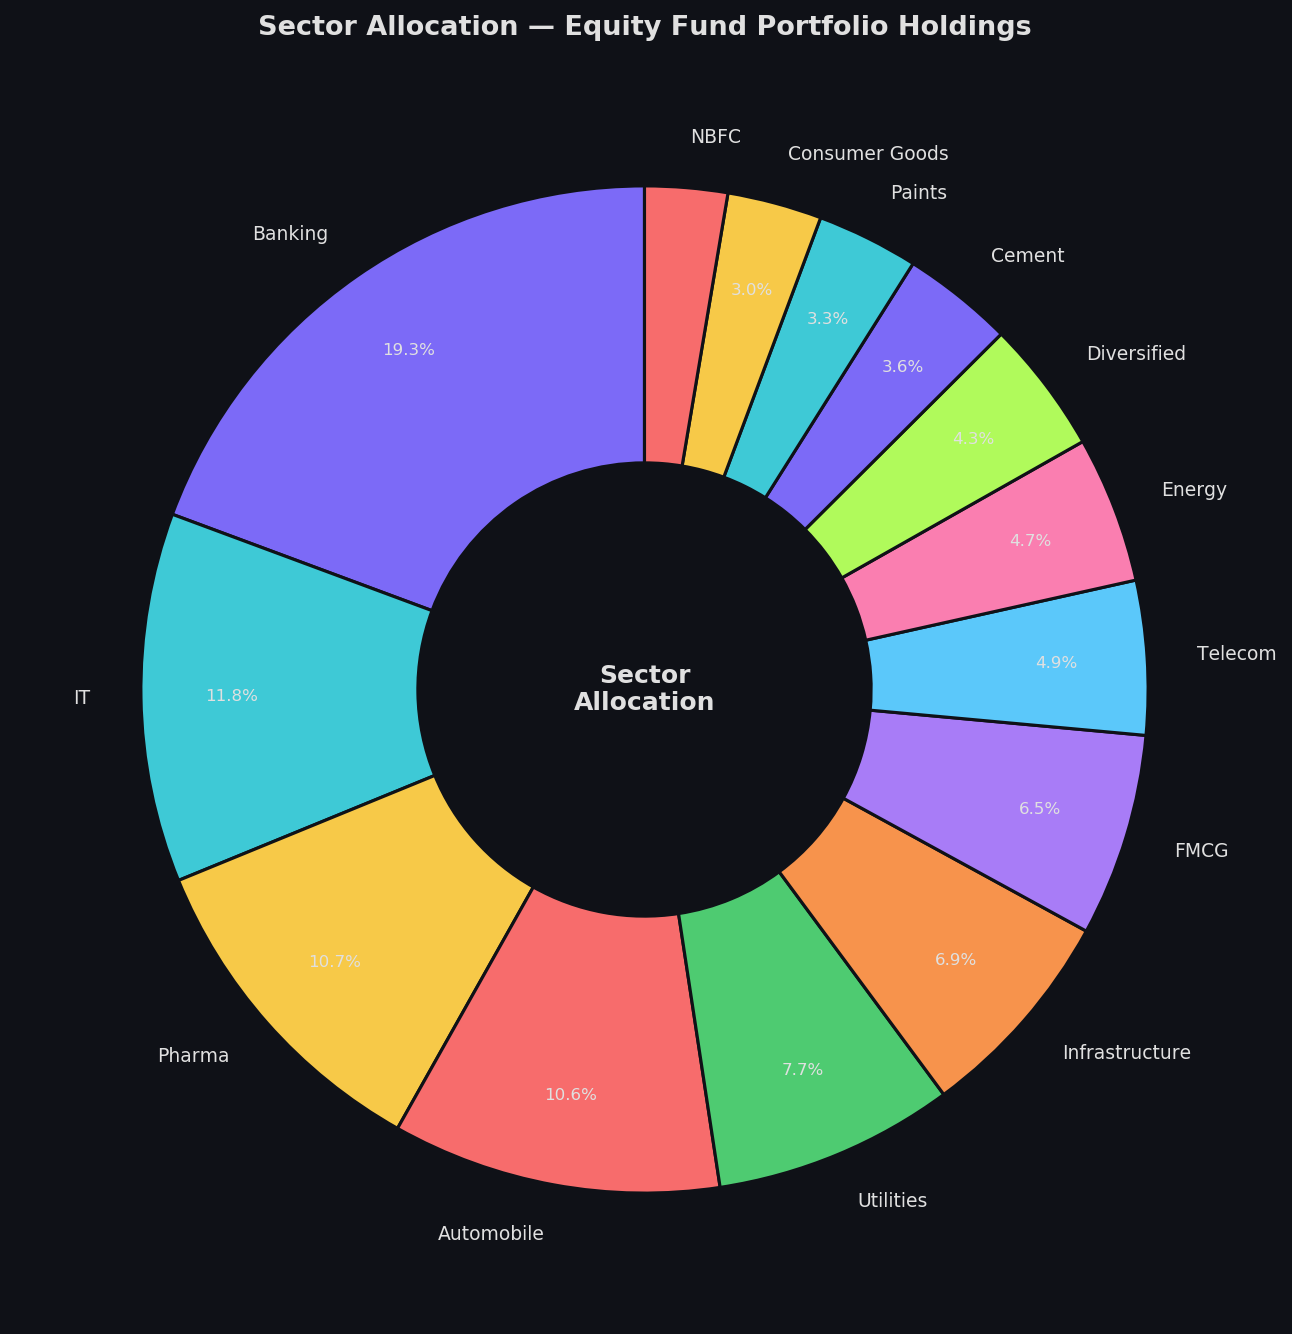

In [62]:
display(Image(f'{CHARTS}/09_sector_donut.png', width=900))

## 11. Risk vs Return Analysis


**Insight 10:** Small Cap funds offer highest 3-year returns (20–24%) but also highest volatility (25%+ std dev). Large Cap funds cluster around 12–16% return with lower risk (14% std dev) — classic risk-return tradeoff. → `10_risk_return_scatter.png`


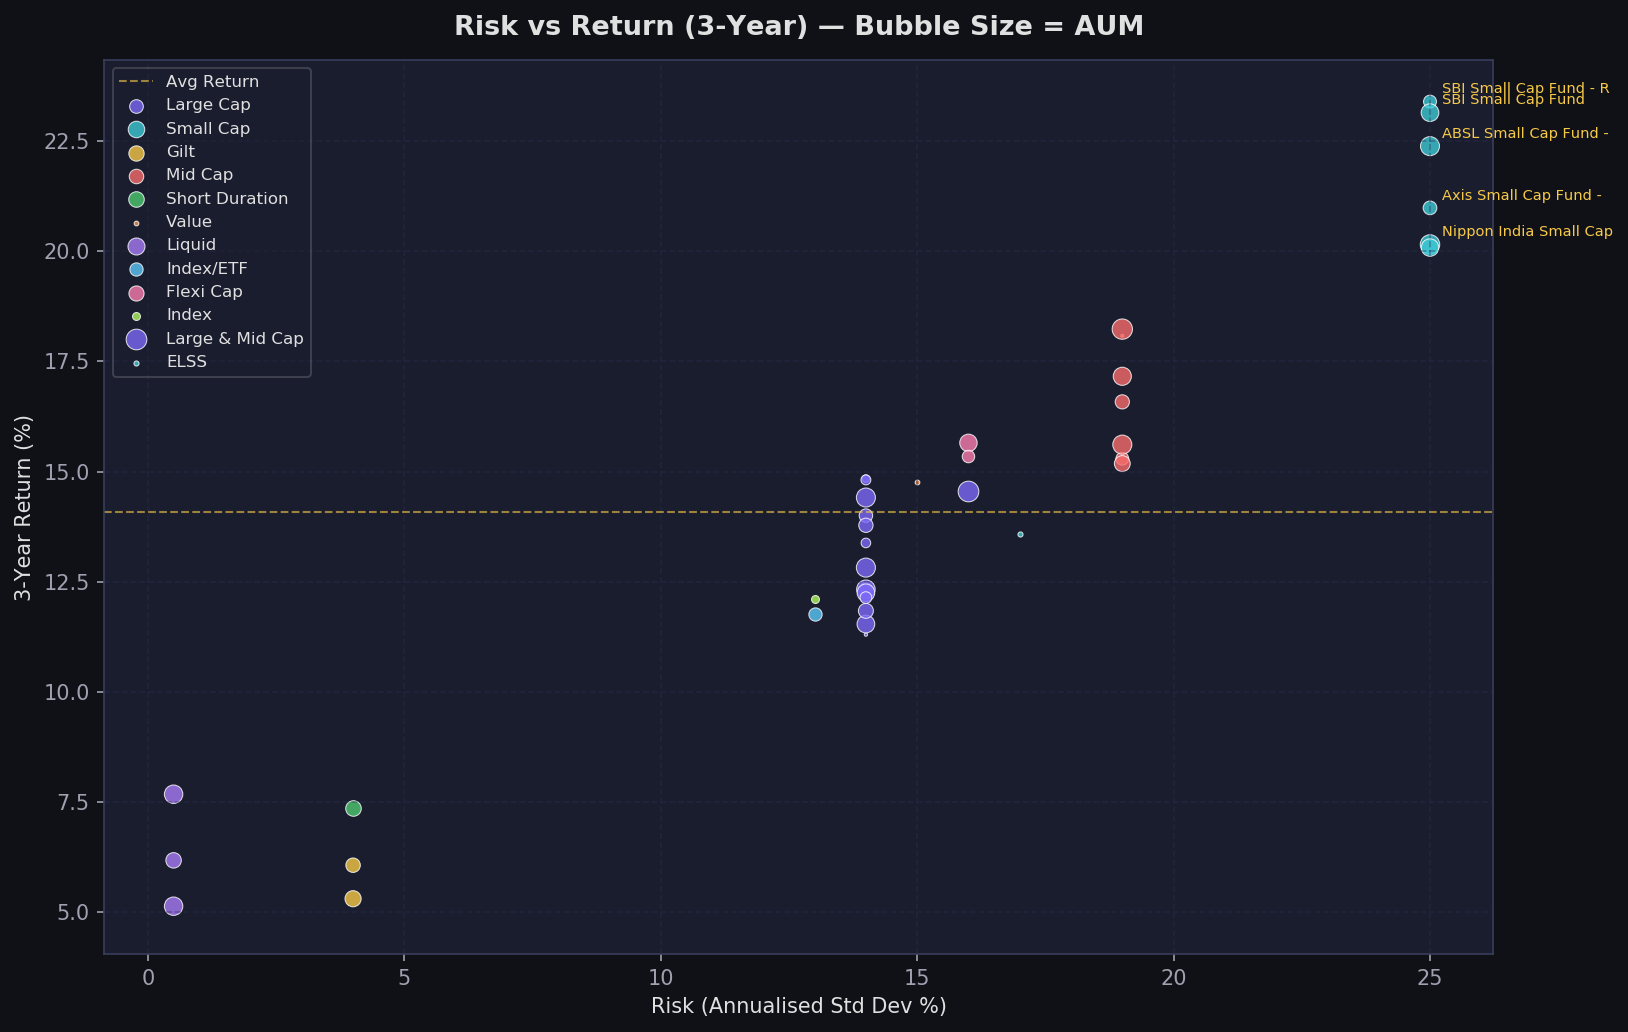

In [63]:
display(Image(f'{CHARTS}/10_risk_return_scatter.png', width=900))

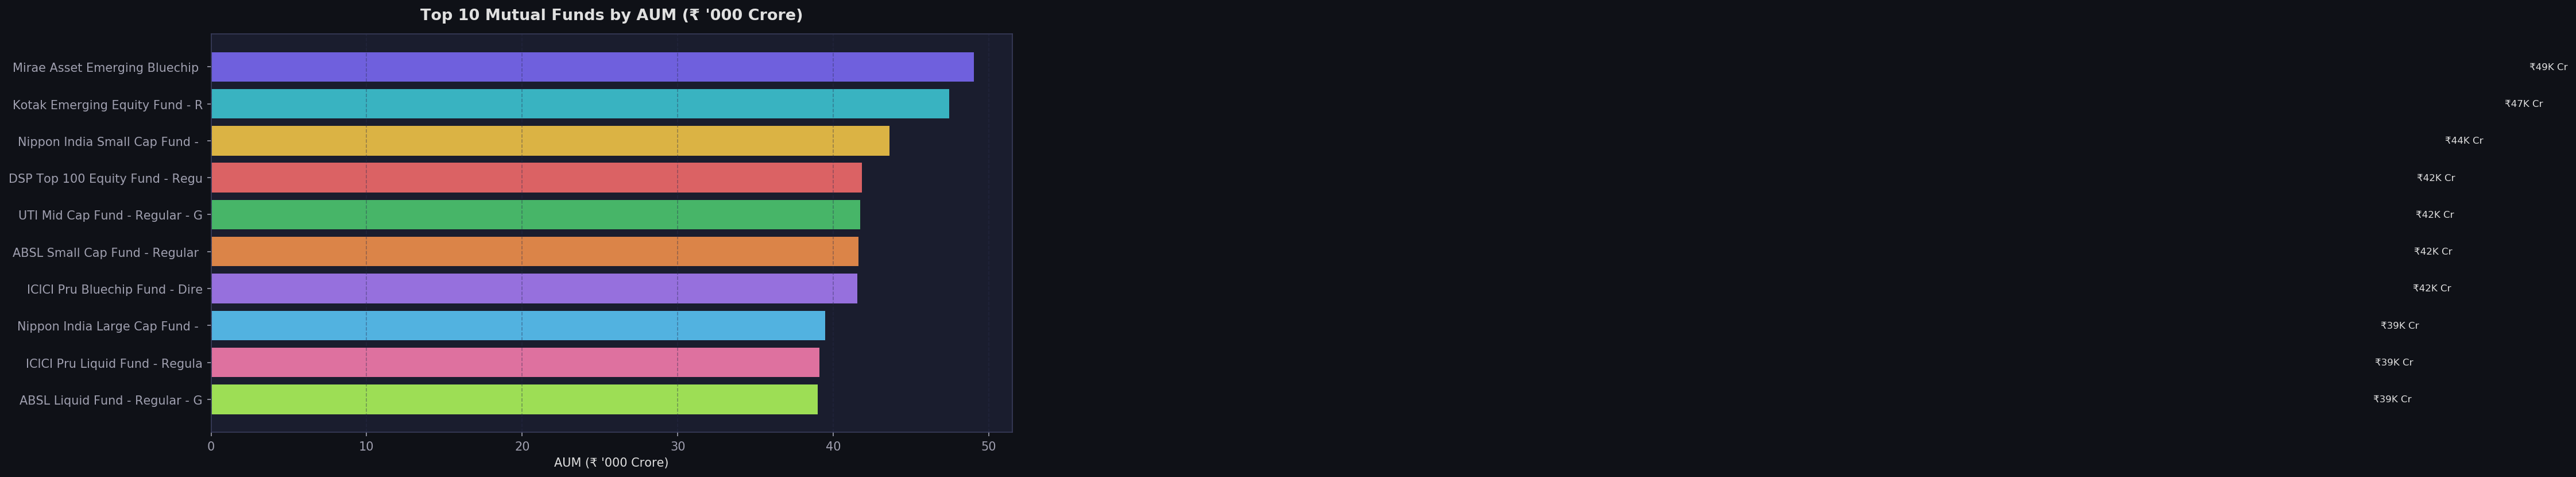

In [64]:
display(Image(f'{CHARTS}/11_top10_aum.png', width=900))

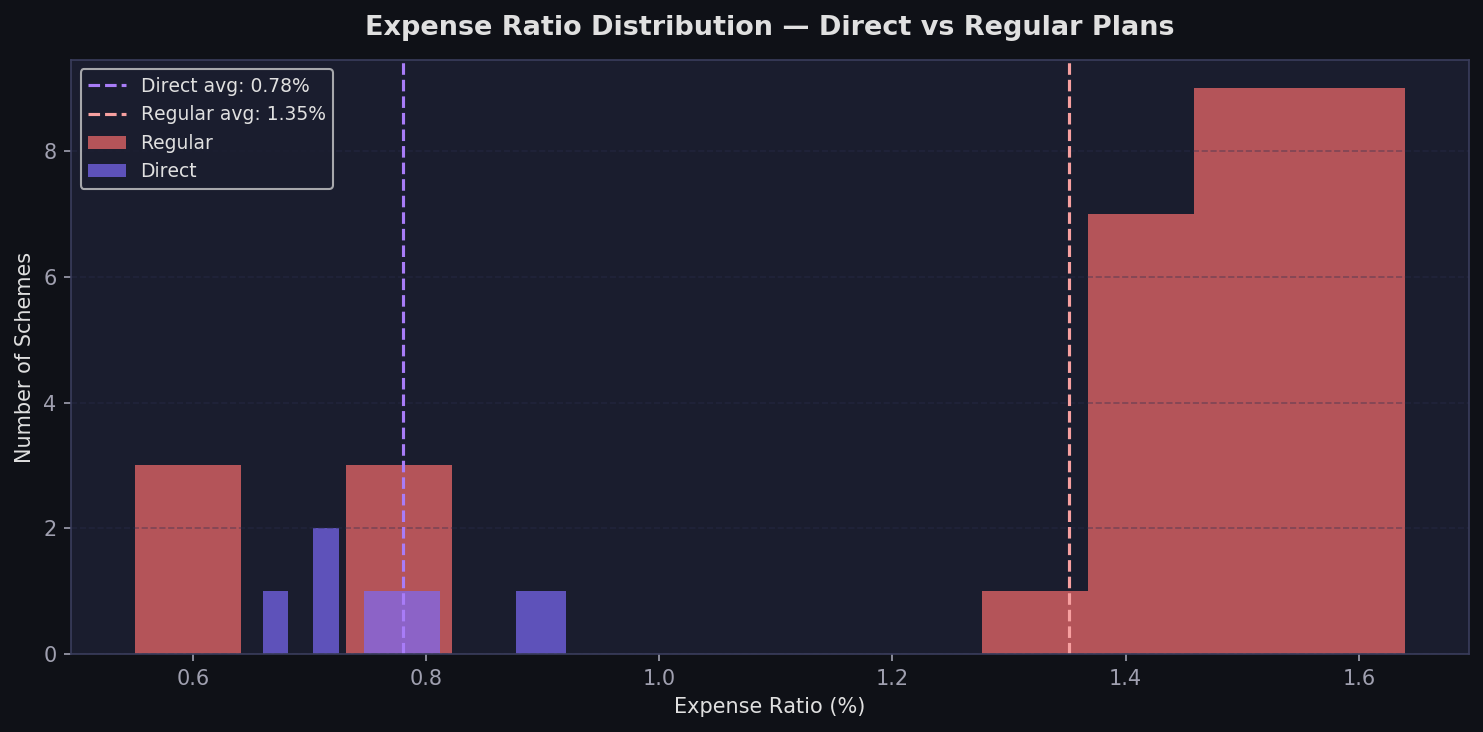

In [65]:
display(Image(f'{CHARTS}/12_expense_ratio.png', width=900))

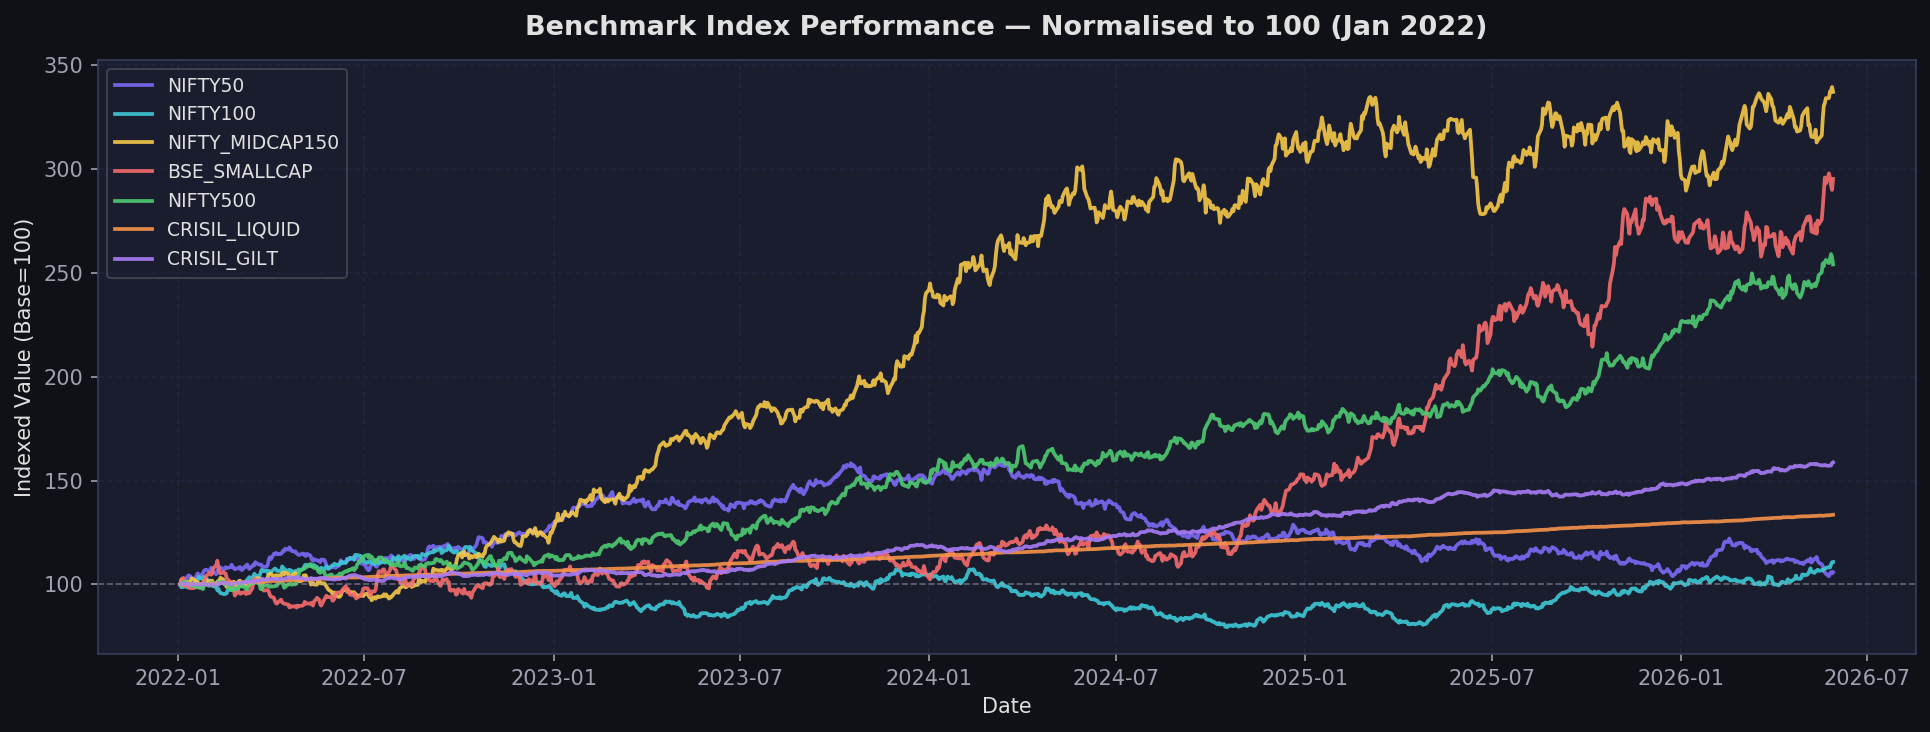

In [66]:
display(Image(f'{CHARTS}/13_benchmark_comparison.png', width=900))

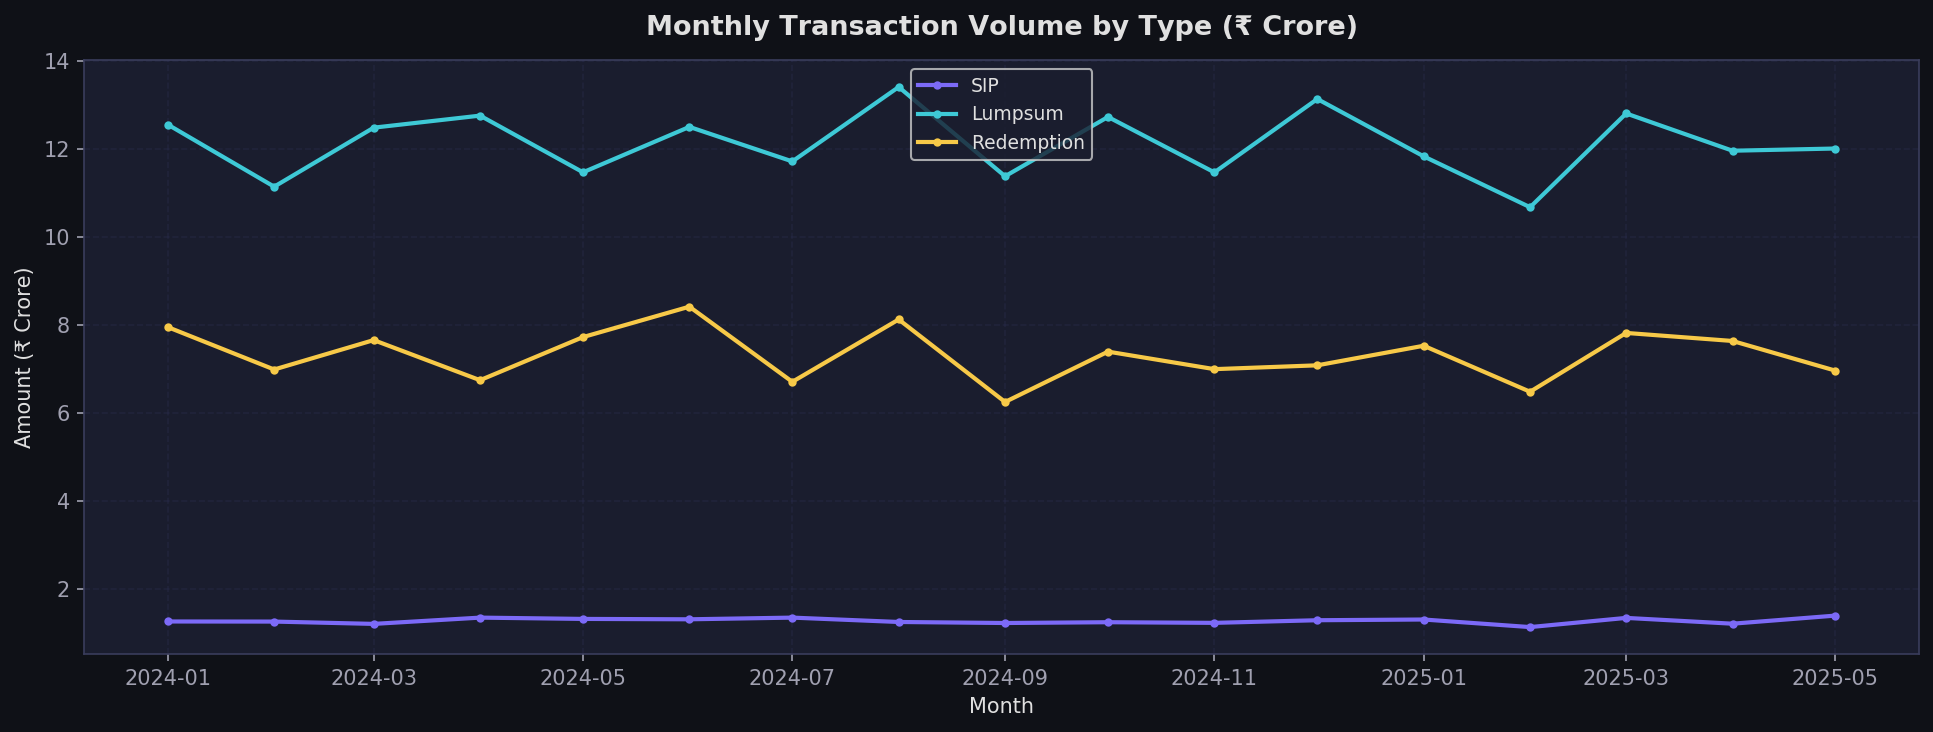

In [67]:
display(Image(f'{CHARTS}/14_transaction_volume.png', width=900))

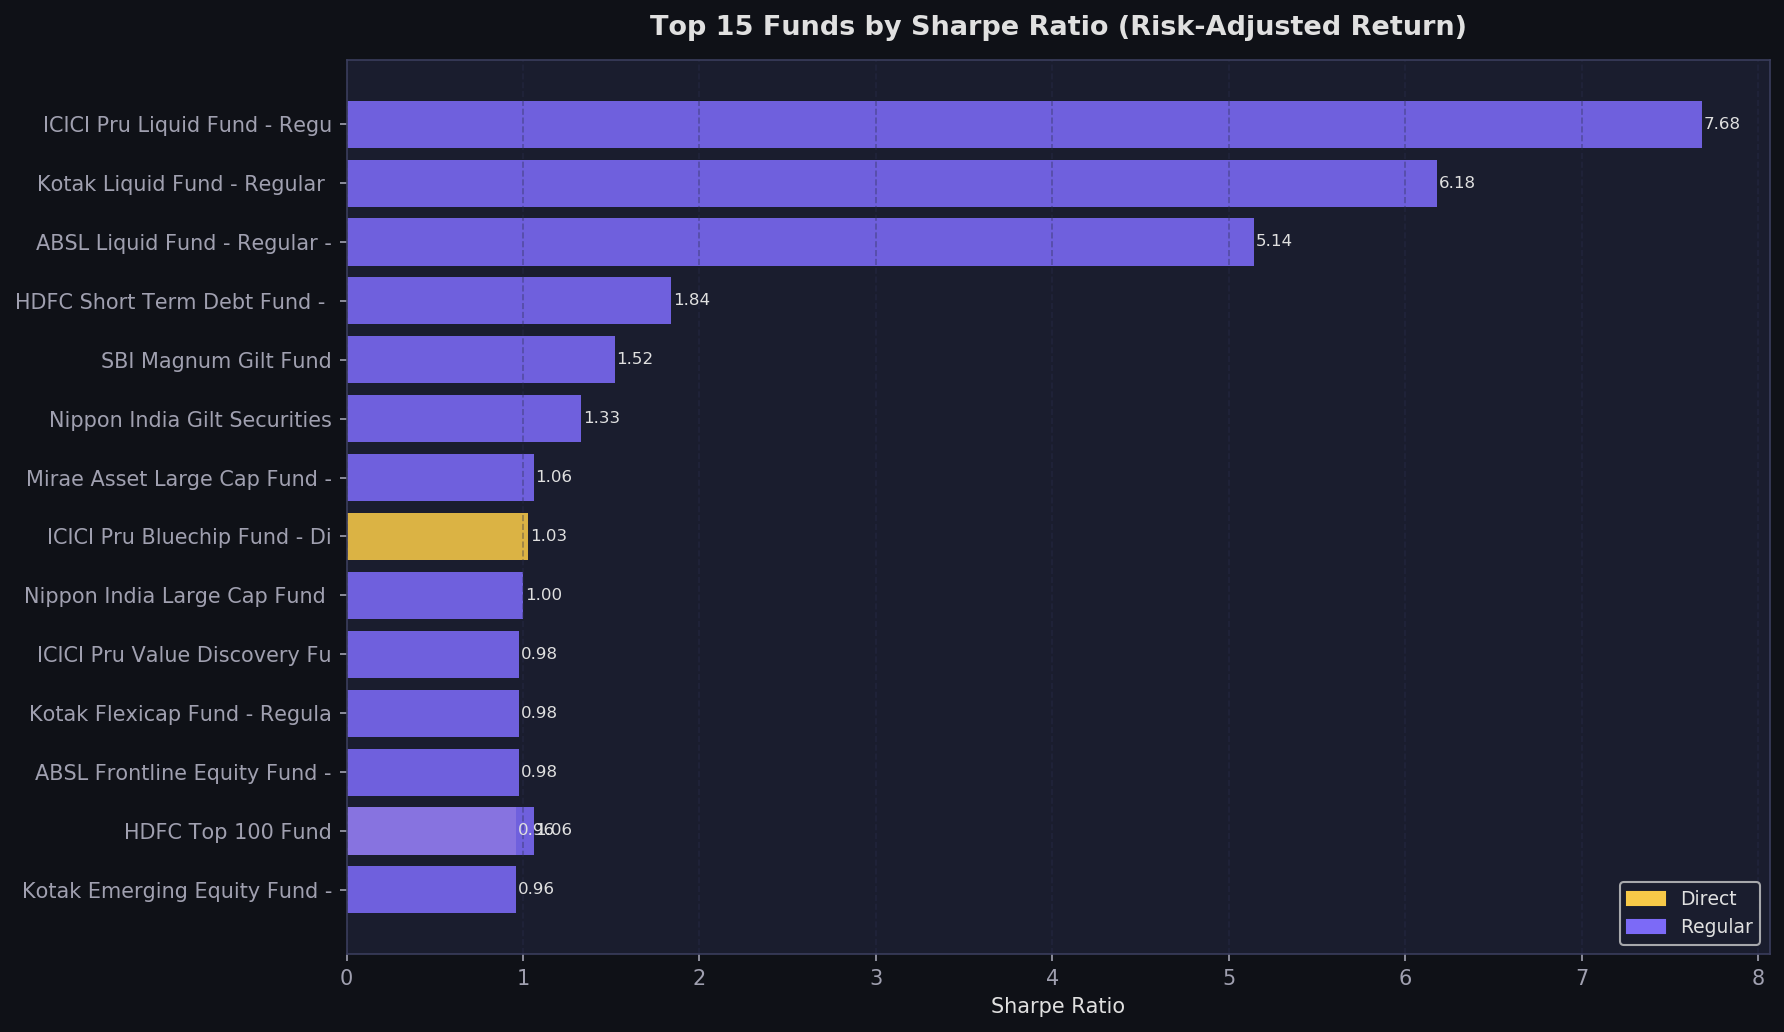

In [68]:
display(Image(f'{CHARTS}/15_sharpe_ranking.png', width=900))

---

## 12. Key EDA Findings Summary

| # | Finding |
|---|--------|
| 1 | Large Cap funds had strong 2023 bull run (+25–40% NAV), followed by Q4 2024 correction (-8–15%) |
| 2 | SBI Mutual Fund dominates with ₹12.5L Cr AUM — 2× the second-largest AMC |
| 3 | SIP inflows grew 169% in 4 years — from ₹11,517 Cr to ₹31,002 Cr (Dec 2025 ATH) |
| 4 | Small Cap & Mid Cap categories attract consistently high net inflows |
| 5 | 26–35 age group is the largest SIP investor cohort |
| 6 | T30 cities lead in volume but B30 cities are growing — financial inclusion signal |
| 7 | Total folios doubled (13.26 Cr → 26.12 Cr) in 4 years |
| 8 | Large Cap funds are highly correlated (0.85–0.97) — limited diversification within category |
| 9 | Banking sector dominates equity fund holdings — reflects India's market structure |
| 10 | Small Cap funds offer highest returns but highest risk — classic risk-return tradeoff |
